In [1]:
import joblib
from deepBreaks.utils import load_obj
import pandas as pd
import numpy as np
#import xgboost as xgb
#from xgboost import plot_tree

top_per_mod = 'gbc.pkl'
# Load your LGBM model from the pickle file
with open(top_per_mod, 'rb') as f:
    model_pipeline = joblib.load(f)
#print(model_pipeline)
#print(model_pipeline.steps[1][1])
actual_model = model_pipeline.steps[1][1] 
#holder = model_pipeline.steps[0][1][4].aa_encoded_seqs_

feature_importances = pd.DataFrame({'feature': actual_model.feature_names_in_, 
                                    'importance': actual_model.feature_importances_})
#feature_importances = feature_importances.sort_values('importance', ascending=True)
feature_importances = feature_importances.set_index('feature')

In [ ]:
n_positions = model_pipeline.named_steps['prep']['aa_prop_encode'].aa_encoded_seqs_().shape([1])

#also want to call the mean function so we can get an accurate array of feature importance! 

In [2]:
feature_importances.head()

,importance
feature,
p1_H1,0.000014
p1_H2,0.000003
p1_H3,0.000059
p1_NCI,0.000008
p2_H1,0.000002


In [3]:
feature_names = actual_model.feature_names_in_.tolist()

In [4]:
aa_prop_list = ['H1','H2','H3','V','P1','P2','SASA','NCI','MASS']
num_props = len(aa_prop_list)


In [5]:
importance_max = feature_importances['importance'].max()
print(importance_max)


0.13961051050905604


In [6]:
for i in range(len(feature_names)):
    feature_importances['importance'][i] = feature_importances['importance'][i] / importance_max

In [7]:
feature_importances.head()

,importance
feature,
p1_H1,0.000104
p1_H2,0.000022
p1_H3,0.000420
p1_NCI,0.000055
p2_H1,0.000012


In [8]:
num_feats = int((feature_importances.last_valid_index().split('_')[0])[1:])
print(num_feats)

293


In [9]:
num_index_list = range(1, num_feats)
print(num_index_list)

range(1, 293)


In [10]:
importance = pd.DataFrame(index=num_index_list, columns=aa_prop_list)


In [11]:
importance.head()

,H1,H2,H3,V,P1,P2,SASA,NCI,MASS
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
for prop in aa_prop_list:
    for feat in feature_names:
        if prop == feat.split('_')[1]:
            i = int((feat.split('_')[0])[1:])
            importance[prop][i] = feature_importances['importance'][feat]
        else:
            pass


In [13]:
importance.fillna(0, inplace=True)
importance.head()

,H1,H2,H3,V,P1,P2,SASA,NCI,MASS
1,0.000104,0.000022,0.000420,0.000000,0.000000,0.000000,0.000000,0.000055,0.000000
2,0.000012,0.000000,0.000003,0.000024,0.000000,0.000000,0.000005,0.000006,0.000000
3,0.000133,0.000003,0.000026,0.000000,0.000000,0.000000,0.000000,0.000012,0.000000
4,0.000057,0.000584,0.000497,0.002128,0.002332,0.000000,0.000000,0.000453,0.001805
5,0.000000,0.000225,0.000000,0.002959,0.000486,0.000715,0.000000,0.000151,0.000000


In [14]:
import matplotlib.pyplot as plt

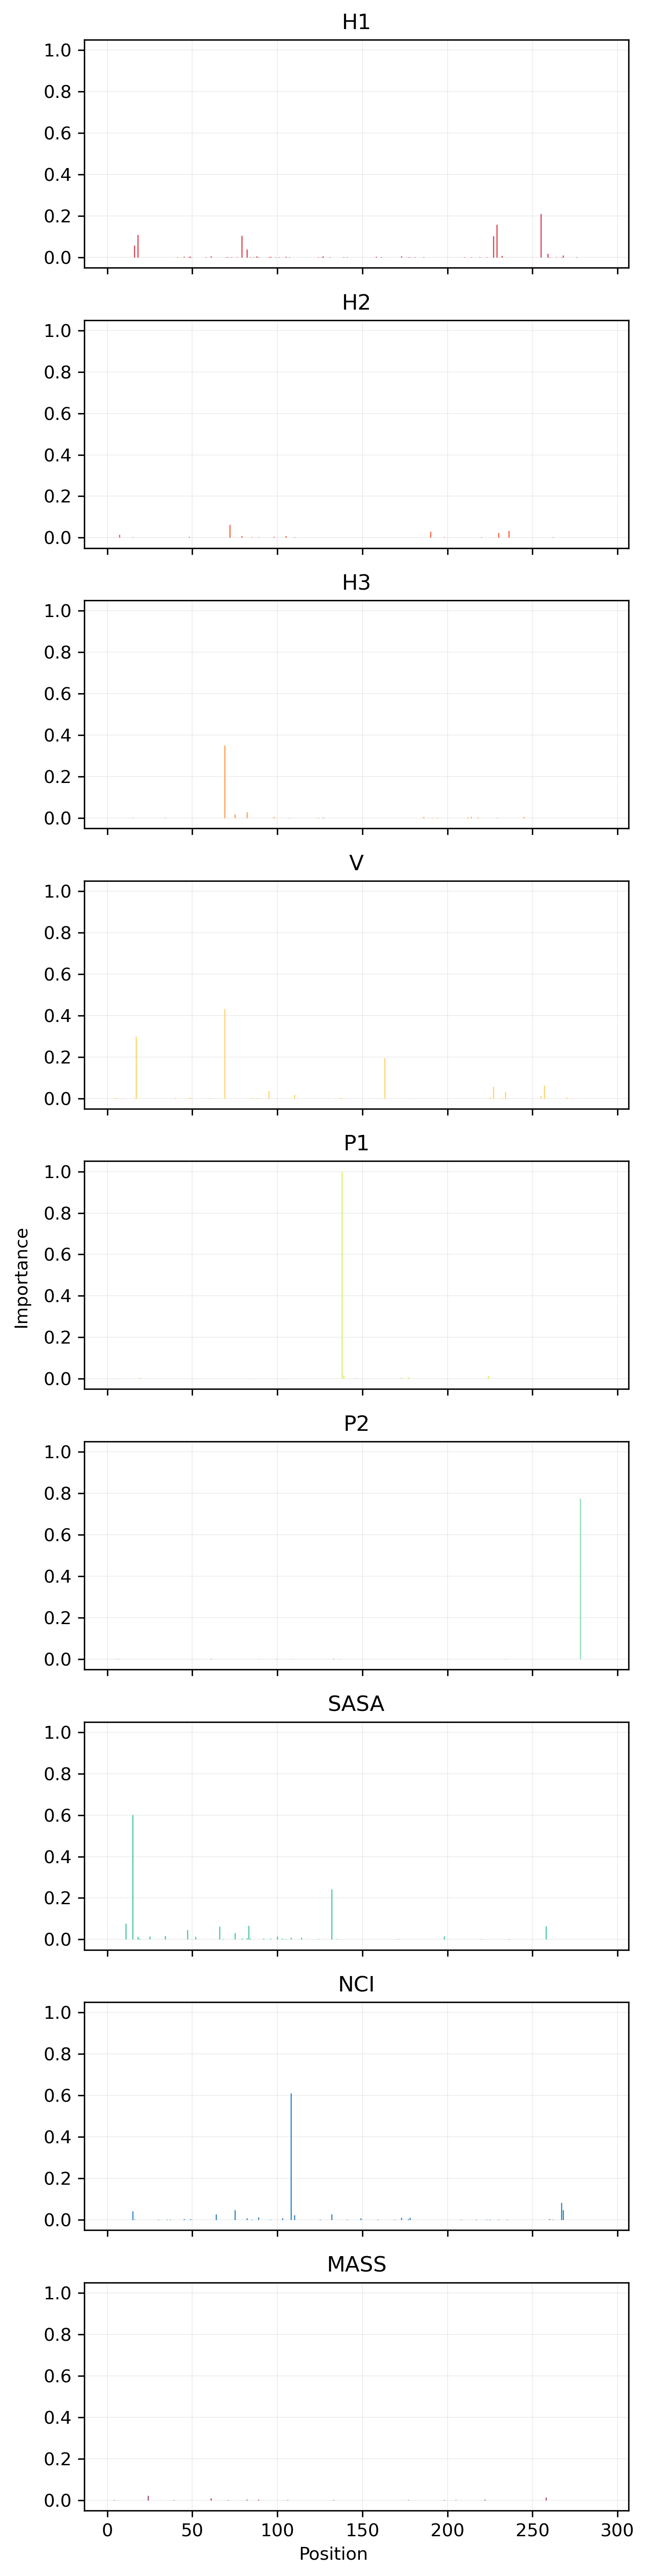

In [19]:
fig, axes = plt.subplots(9, figsize=(5, 20), dpi=300, sharex=True, sharey=True)

color_list = ['#d5283a', '#f44d25', '#fd9136', '#fece58','#d0f55c', '#80daa9', '#33c290', '#1574b5', '#9F2B68']
# Iterate over each subplot and plot vlines for each property column
for i, ax in enumerate(axes.flatten()):
    property_col = aa_prop_list[i]
    ax.vlines(x=num_index_list, ymin=0, ymax=importance[property_col],
              color=color_list[i], linewidth=.7, alpha=0.8)
    ax.set_title(property_col)
    ax.grid(True, linewidth=.1)

# Set common x and y labels
fig.text(0.5, 0, 'Position', ha='center')
fig.text(0, 0.5, 'Importance', va='center', rotation='vertical')


plt.tight_layout()
plt.show()

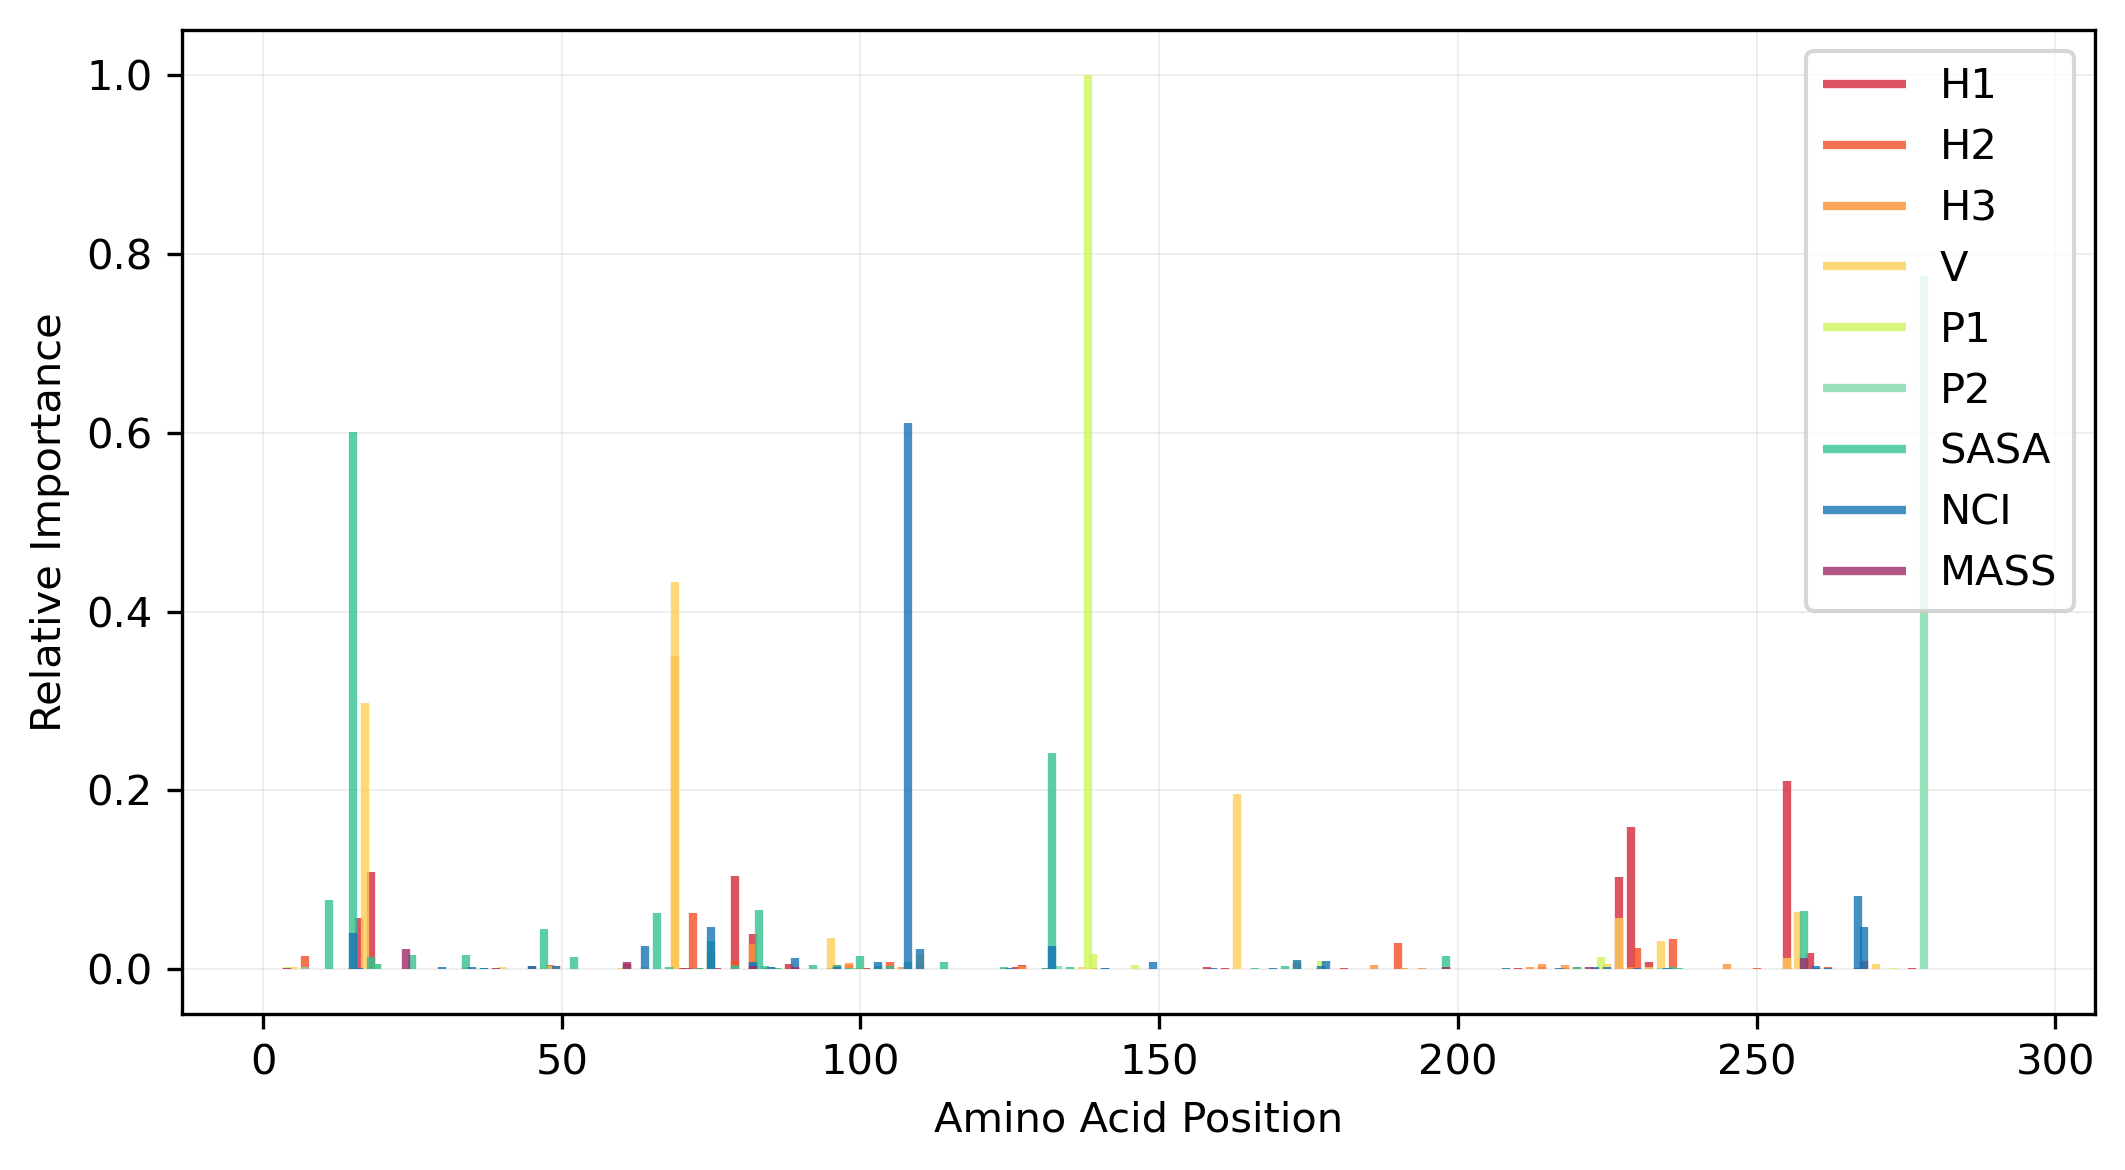

In [20]:
fig, ax = plt.subplots(figsize=(7.2, 4), dpi=300)

color_list = ['#d5283a', '#f44d25', '#fd9136', '#fece58','#d0f55c', '#80daa9', '#33c290', '#1574b5', '#9F2B68']
# Iterate over each subplot and plot vlines for each property column
for i in range(9):
    property_col = aa_prop_list[i]
    ax.vlines(x=num_index_list, ymin=0, ymax=importance[property_col],
              color=color_list[i], linewidth=2, alpha=0.8)

#Add legend for line colors
ax.legend(labels = aa_prop_list)

# Add grid
ax.grid(True, linewidth=.1)

# Set common x and y labels
ax.set_xlabel('Amino Acid Position')
ax.set_ylabel('Relative Importance')

plt.tight_layout()
plt.show()
